# Stage 3 — RL with GRPO (from scratch)

The core R1 trick: **no critic, no human labels**. For each prompt:

1. Sample `G` completions from the current model.
2. Score each with a rule-based reward (is the answer right? is the format right?).
3. Compute **group-relative advantages**: `(r − mean) / (std + eps)`.
4. REINFORCE update: push up log-prob of completions with positive advantage.

That's GRPO. ~60 lines below.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, random, re
torch.manual_seed(0); random.seed(0)

VOCAB = list('0123456789+=TA .')
stoi = {c: i for i, c in enumerate(VOCAB)}; itos = {i: c for c, i in stoi.items()}
V, PAD, EOS, BLOCK = len(VOCAB), stoi[' '], stoi['.'], 24
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

class TinyLM(nn.Module):
    def __init__(self, V, d=64, h=4, L=2, block=BLOCK):
        super().__init__()
        self.tok = nn.Embedding(V, d); self.pos = nn.Embedding(block, d)
        self.blocks = nn.ModuleList([nn.TransformerEncoderLayer(d, h, dim_feedforward=4*d, batch_first=True, activation='gelu') for _ in range(L)])
        self.head = nn.Linear(d, V)
    def forward(self, x):
        T = x.shape[1]
        h = self.tok(x) + self.pos(torch.arange(T, device=x.device))
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        for blk in self.blocks: h = blk(h, src_mask=mask)
        return self.head(h)

model = TinyLM(V)
model.load_state_dict(torch.load('cold_start.pt'))
print('loaded cold-start checkpoint')

loaded cold-start checkpoint


In [2]:
# --- Reward function (rule-based, R1 style) ---
def reward(prompt, completion):
    text = prompt + completion
    m = re.match(r'(\d)\+(\d)=', prompt)
    if not m: return 0.0
    target = int(m.group(1)) + int(m.group(2))
    r = 0.0
    if 'T' in completion and 'A' in completion: r += 0.1   # format reward
    ans = re.search(r'A(\d+)\.', text)
    if ans and int(ans.group(1)) == target: r += 1.0       # accuracy reward
    return r

In [3]:
# --- Sample G completions and compute log-probs in one pass ---
def sample_completion(prompt_ids, max_new=16):
    x = prompt_ids.clone()
    logps = []
    for _ in range(max_new):
        logits = model(x[:, -BLOCK:])[:, -1, :]
        probs = F.softmax(logits, -1)
        nxt = torch.multinomial(probs, 1)
        logps.append(F.log_softmax(logits, -1).gather(1, nxt))
        x = torch.cat([x, nxt], 1)
        if nxt.item() == EOS: break
    return x, torch.cat(logps, 1).sum(1)  # sum log-prob over generated tokens

def grpo_step(prompt_str, G=4):
    prompt_ids = torch.tensor([encode(prompt_str)])
    completions, logps, rewards = [], [], []
    for _ in range(G):
        full, lp = sample_completion(prompt_ids)
        comp_ids = full[0, len(prompt_ids[0]):].tolist()
        comp_str = decode(comp_ids)
        completions.append(comp_str)
        logps.append(lp)
        rewards.append(reward(prompt_str, comp_str))
    r = torch.tensor(rewards)
    adv = (r - r.mean()) / (r.std() + 1e-6)              # group-relative advantage
    loss = -(torch.cat(logps) * adv).mean()              # REINFORCE
    return loss, r.mean().item(), completions

In [4]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
history = []
for step in range(150):
    a, b = random.randint(0,9), random.randint(0,9)
    prompt = f'{a}+{b}='
    loss, mean_r, comps = grpo_step(prompt, G=4)
    opt.zero_grad(); loss.backward(); opt.step()
    history.append(mean_r)
    if step % 25 == 0:
        print(f'step {step:3d}  mean_r {mean_r:.2f}  e.g. {prompt}{comps[0]}')

step   0  mean_r 0.00  e.g. 6+6=T6+62.


step  25  mean_r 0.55  e.g. 1+3=T1+34A4.


step  50  mean_r 0.83  e.g. 4+8=T4+84A12.


step  75  mean_r 0.60  e.g. 3+2=T4+2=A13.


step 100  mean_r 0.10  e.g. 6+4=T6+4A94.


step 125  mean_r 0.10  e.g. 9+0=T9+0AA10.


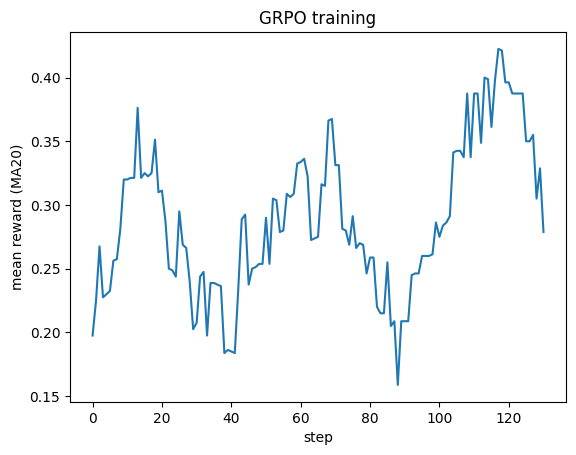

In [5]:
import matplotlib.pyplot as plt
# moving average
import numpy as np
h = np.array(history)
ma = np.convolve(h, np.ones(20)/20, mode='valid')
plt.plot(ma); plt.xlabel('step'); plt.ylabel('mean reward (MA20)'); plt.title('GRPO training'); plt.show()

In [6]:
@torch.no_grad()
def generate(prompt, max_new=16):
    x = torch.tensor([encode(prompt)])
    for _ in range(max_new):
        logits = model(x[:, -BLOCK:])[:, -1, :]
        nxt = torch.argmax(logits, -1, keepdim=True)
        x = torch.cat([x, nxt], 1)
        if nxt.item() == EOS: break
    return decode(x[0].tolist())

def pass_rate(n=50):
    correct = 0
    for _ in range(n):
        a, b = random.randint(0,9), random.randint(0,9)
        out = generate(f'{a}+{b}=')
        m = re.search(r'A(\d+)\.', out)
        if m and int(m.group(1)) == a + b: correct += 1
    return correct / n

print(f'pass-rate after GRPO: {pass_rate():.0%}')
torch.save(model.state_dict(), 'after_grpo.pt')

pass-rate after GRPO: 22%


## Takeaway

We just did **RL with no critic, no value network, no human labels** — only a Python `reward()` function. This is the heart of R1.

Compare your pass-rate to notebook 03. The model is solving the same task with the same parameters — just nudged by group-relative advantage.